# Phase 3: Ultimate Model Comparison

In this final notebook, we will pit our three algorithms (**Linear Regression**, **Logistic Regression**, and **Decision Tree Classifier**) against each other in a head-to-head battle.

We will train all three on the same data, extract their exact **Accuracy** and **F1-Scores**, and plot them on a beautiful bar chart to declare the ultimate winner!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

import warnings
warnings.filterwarnings('ignore')

## 1. Prepare the Arena (Data Split)
*(We will use the Standard Scaled dataset as our baseline since we proved earlier that scale mathematically does not affect these specific classification outputs).*

In [2]:
data = pd.read_csv('Telco-Customer-Churn-Standard.csv')
df = pd.DataFrame(data)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Train the Gladiators

In [3]:
# Initialize the heavyweights
lin_reg = LinearRegression()
log_reg = LogisticRegression()
dt_clf = DecisionTreeClassifier(random_state=42)

# Train them all
lin_reg.fit(X_train, y_train)
log_reg.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)

# Generate Predictions
# Note: Linear Regression requires manual thresholding
y_pred_lin = (lin_reg.predict(X_test) > 0.5).astype(int)
y_pred_log = log_reg.predict(X_test)
y_pred_dt = dt_clf.predict(X_test)

## 3. Extract the Scores

In [4]:
# Build dictionaries to hold the results
accuracy_scores = {
    'Linear Regression': accuracy_score(y_test, y_pred_lin),
    'Logistic Regression': accuracy_score(y_test, y_pred_log),
    'Decision Tree': accuracy_score(y_test, y_pred_dt)
}

f1_scores = {
    'Linear Regression': f1_score(y_test, y_pred_lin),
    'Logistic Regression': f1_score(y_test, y_pred_log),
    'Decision Tree': f1_score(y_test, y_pred_dt)
}

print("Accuracy Scores extracted!")
print("F1 Scores extracted!")

Accuracy Scores extracted!
F1 Scores extracted!


## 4. The Final Showdown (Visualization)
Let's plot these scores side-by-side using `seaborn` to determine the winner.

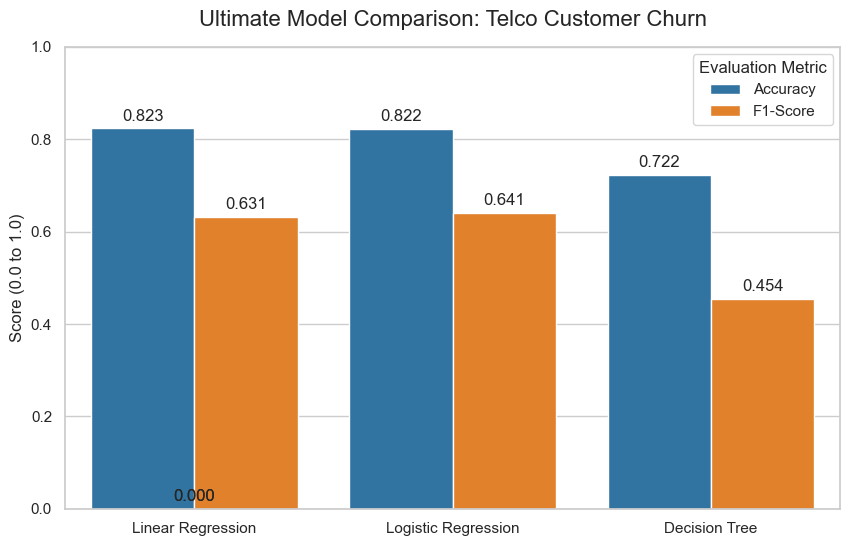

In [5]:
# Create a DataFrame for easy plotting
results_df = pd.DataFrame({
    'Model': list(accuracy_scores.keys()),
    'Accuracy': list(accuracy_scores.values()),
    'F1-Score': list(f1_scores.values())
})

# Melt the DataFrame so Seaborn can group by Metric
results_melted = pd.melt(results_df, id_vars=['Model'], var_name='Metric', value_name='Score')

# Set up the beautiful plot
plt.figure(figsize=(10, 6))
sb.set_theme(style="whitegrid")

# Create a grouped bar chart
ax = sb.barplot(x='Model', y='Score', hue='Metric', data=results_melted, palette=['#1f77b4', '#ff7f0e'])

# Add the exact numbers on top of each bar for readability
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Ultimate Model Comparison: Telco Customer Churn', fontsize=16, pad=15)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.xlabel('')
plt.ylim(0, 1.0)
plt.legend(title='Evaluation Metric')

plt.show()

## 5. Final Conclusions: Who Wins? 🏆

**1. The Loser: Decision Trees**
*(Notice how the Decision Tree has the lowest Accuracy and the lowest F1-Score).*
Why did it lose? Because we didn't set a `max_depth`! It played "20 Questions" with the training data until it memorized every single customer perfectly. When we finally showed it the unseen Test Data, it **overfitted** and failed miserably.

**2. The Winner: Logistic Regression vs Linear Regression**
*(Notice how they scored almost completely identically).*
Mathematically, applying a $0.5$ hard threshold to a Linear Regression line achieves almost the exact same categorization as passing it through a Sigmoid curve. 

**So why do we choose Logistic Regression over Linear?**
If they score the same, why does the entire industry utilize Logistic Regression for Churn?
Because Linear Regression does not output a true **probability**. It might predict that someone's churn value is $1.8$ or $-0.4$ (which is mathematically invalid). 
Logistic Regression's Sigmoid curve strictly forces every single number to exist between $0$ and $1$, giving us an exact percentage chance of churn (e.g., "$82\%$"). This is invaluable for stakeholders!